**Quantum Random Number Generator using Superposition**

In [72]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
simulator = AerSimulator()
shots = 1000
qc = QuantumCircuit(1,1)
qc.h(0)
qc.measure(0,0)
job = simulator.run(qc, shots=shots)
counts = job.result().get_counts()

print("Quantum Random Bit Distribution")
print(counts)

Quantum Random Bit Distribution
{'1': 504, '0': 496}


In [70]:
#Generating a Quantum Random Bit Sequence
memory_job = simulator.run(qc, shots=64, memory=True)
memory = memory_job.result().get_memory()
bit_string = "".join(memory)
print(bit_string)

1100101101110110011101000011010011010000000101001000101010100001


**Visualizing Quantum Randomness**

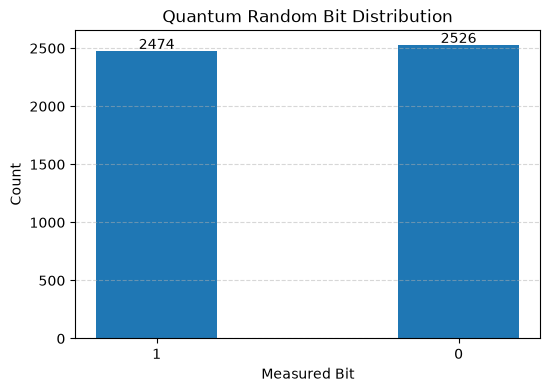

In [76]:
#Histogram And Visualization
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
sim=AerSimulator()
qc=QuantumCircuit(1,1)
qc.h(0)
qc.measure(0,0)
result=sim.run(qc,shots=5000).result()
counts=result.get_counts()
labels=list(counts.keys())
values=list(counts.values())
plt.figure(figsize=(6,4))
bars=plt.bar(labels,values,width=0.4)
plt.title("Quantum Random Bit Distribution")
plt.xlabel("Measured Bit")
plt.ylabel("Count")
for bar in bars:
    height=bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,height+20,F"{int(height)}",ha="center")

plt.grid(axis='y',linestyle='--',alpha=0.5)
        
plt.show()

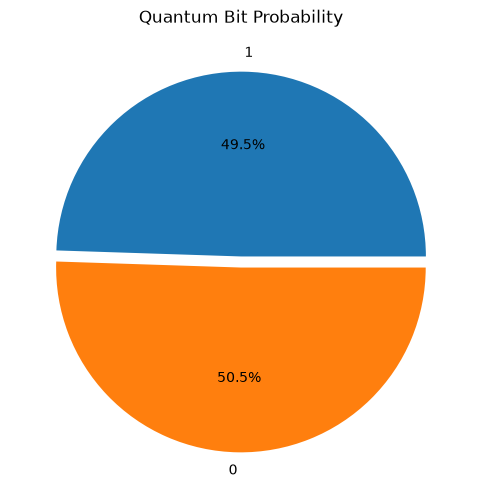

In [78]:
#Bit Probability
plt.figure(figsize=(6,6))
plt.pie(values,labels=labels,autopct="%1.1f%%",explode=(0.03,0.03))
plt.title("Quantum Bit Probability")
plt.show()

**Statistical Analysis of Quantum Measurements**

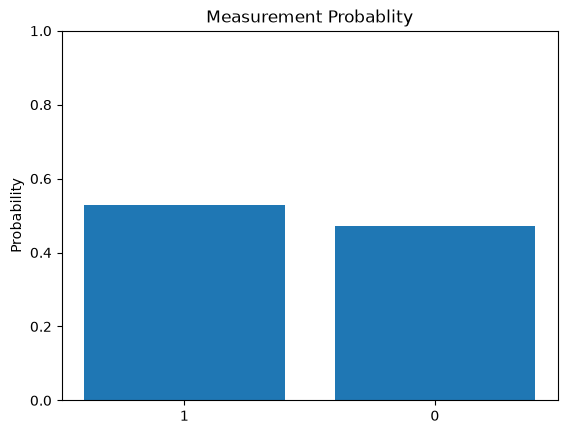

In [120]:
#Probability of the Measurement
total=sum(values)
prob=[i/total for i in values]
plt.bar(labels,prob)
plt.ylim(0,1)
plt.ylabel("Probability")
plt.title("Measurement Probablity")
plt.show()

In [119]:
import numpy as np
zeroes=counts.get("0",0)
ones=counts.get("1",0)
data=np.array([zeroes,ones])

print("Mean: ",np.mean(data))
print("Median: ",np.median(data))
print("Variance: ",np.var(data))
print("Standard Deviation: ",np.std(data))
print("Minimum: ",np.min(data))
print("Maximum: ",np.max(data))

total=zeroes+ones
print("Probability of 0: ",zeroes/total)
print("Probability of 1: ",ones/total)



Mean:  250.0
Median:  250.0
Variance:  196.0
Standard Deviation:  14.0
Minimum:  236
Maximum:  264
Probability of 0:  0.472
Probability of 1:  0.528


**Classical VS Quantum Randomness**

In [80]:
#Classical Random bits generation
import random 
classical=[random.randint(0,1) for i in range(1000)]
zeroes=classical.count(0)
ones=classical.count(1)
print("no of zeroes: ",zeroes)
print("no of oneses: ",ones)


no of zeroes:  480
no of oneses:  520


In [81]:
#Quantum random bit generation
memory=sim.run(qc,shots=1000,memory=True).result().get_memory()
quantum=[int(i) for i in memory]
q0=quantum.count(0)
q1=quantum.count(1)
print("no of zeroes: ",q0)
print("no of oneses: ",q1)

no of zeroes:  503
no of oneses:  497


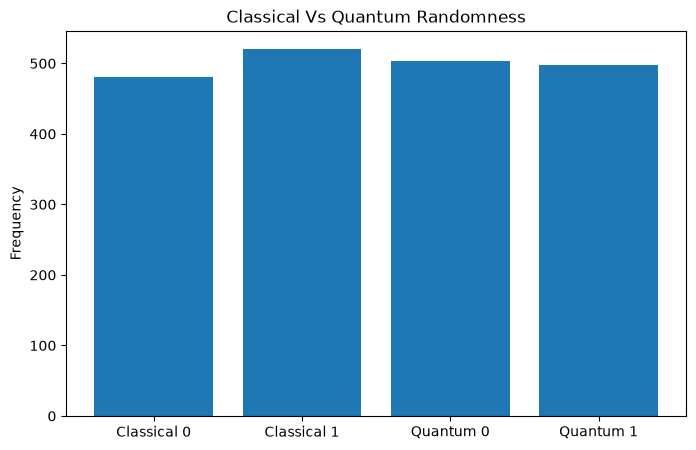

In [82]:
#compatison of classical vs quantum
import matplotlib.pyplot as plt
labels=["Classical 0","Classical 1","Quantum 0","Quantum 1"]
values=[zeroes,ones,q0,q1]
plt.figure(figsize=(8,5))
plt.bar(labels,values)
plt.ylabel("Frequency")
plt.title("Classical Vs Quantum Randomness")
plt.show()

**Multi-Qubit Quantum Random Number Generator**

In [83]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
sim=AerSimulator()
qc=QuantumCircuit(8,8)
for i in range(8):
    qc.h(i)
qc.measure(range(8),range(8))
res=sim.run(qc,shots=20,memory=True).result()
num=res.get_memory()
print(num)

['01000110', '00110101', '01111110', '00111101', '10100110', '00001111', '11111111', '00001110', '10101111', '00001001', '11011100', '01010010', '01110111', '11011110', '10001011', '01000110', '10010101', '11001111', '01000110', '10001000']


**Quantum Entropy Analysis**

In [114]:
import math
sim=AerSimulator()
qc=QuantumCircuit(1,1)
qc.h(0)
qc.measure(0,0)
result=sim.run(qc,shots=5000).result()
counts=result.get_counts()
print("Counts: ",counts)
val=list(counts.values())
total=sum(val)
entropy=0
for count in val:
    p=count/total
    if p>0:
        entropy-=p*math.log2(p)
print("Shanon Entropy: ",entropy)

Counts:  {'1': 2560, '0': 2440}
Shanon Entropy:  0.9995844639313985


**Live Quantum Randomness Dashboard**

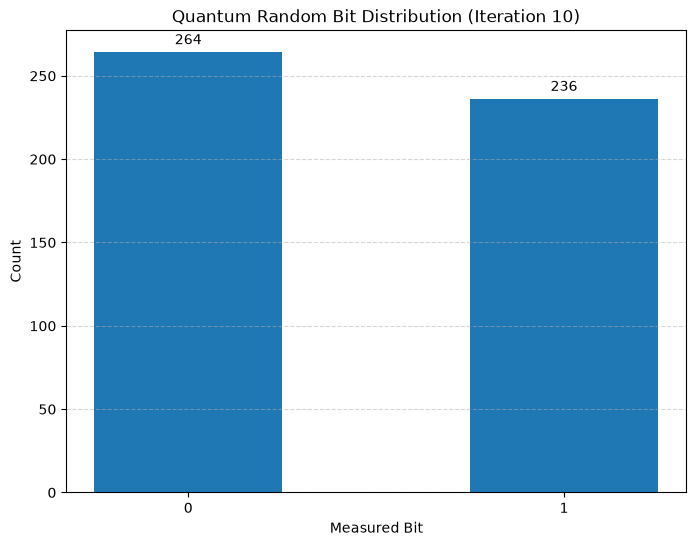

In [121]:
from IPython.display import clear_output
import matplotlib.pyplot as plt
import time
for i in range(10):
    clear_output(wait=True)
    result=sim.run(qc,shots=500).result()
    counts=result.get_counts()
    labels = list(counts.keys())
    values = list(counts.values())
    plt.figure(figsize=(8,6))
    bars=plt.bar(labels,values,width=0.5)
    plt.title(f"Quantum Random Bit Distribution (Iteration {i+1})")
    plt.xlabel("Measured Bit")
    plt.ylabel("Count")
    for bar in bars:
        height=bar.get_height()
        plt.text(bar.get_x()+bar.get_width()/2,height+5,f"{int(height)}",ha="center")
    plt.grid(axis="y",linestyle="--",alpha=0.5)
    plt.show()
    time.sleep(1)